## 1. Prep

In [98]:
import warnings
warnings.filterwarnings("ignore")
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, precision_recall_curve, roc_auc_score, confusion_matrix,
    average_precision_score
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """Save current figure to ../output/<name>.pdf then display it."""
    path = OUTPUT_DIR / f"{name}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"  [saved] {path}")
    plt.show()

## 2. Load and clean

In [91]:
print("Loading data...")
df = pd.read_csv("../data/nbaallelo.csv")
df["date_game"] = pd.to_datetime(df["date_game"], errors="coerce")
df = df.sort_values(["date_game", "gameorder", "game_id"]).reset_index(drop=True)

if "_iscopy" in df.columns:
    df = df.drop(columns="_iscopy")

keep_cols = [
    "gameorder", "game_id", "lg_id", "year_id", "date_game", "seasongame",
    "is_playoffs", "team_id", "fran_id", "pts", "elo_i", "elo_n",
    "win_equiv", "opp_id", "opp_fran", "opp_pts", "opp_elo_i", "opp_elo_n",
    "game_location", "game_result", "forecast", "notes",
]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()

# Labels + base features
UPSET_THRESHOLD = 0.40
df["win"]        = (df["game_result"] == "W").astype(int)
df["upset"]      = ((df["forecast"] <= UPSET_THRESHOLD) & (df["win"] == 1)).astype(int)
df["elo_gap"]    = df["elo_i"] - df["opp_elo_i"]
df["is_home"]    = (df["game_location"] == "H").astype(int)
df["is_away"]    = (df["game_location"] == "A").astype(int)
df["is_neutral"] = (df["game_location"] == "N").astype(int)
df["point_diff"] = df["pts"] - df["opp_pts"]
df["elo_delta"]  = df["elo_n"] - df["elo_i"]

df = df.sort_values(["fran_id", "date_game", "gameorder", "game_id"]).reset_index(drop=True)
print(f"Upset rate: {df['upset'].mean():.4f}")

Loading data...


FileNotFoundError: [Errno 2] No such file or directory: '../data/nbaallelo.csv'

## 3. Feature Engineering


In [92]:
def add_features(data, group_col="fran_id"):
    data = data.copy()
    g = data.groupby(group_col, group_keys=False)

    # ── Original rolling-10 features (MODEL A) ──────────────
    data["win_rolling_10"]       = g["win"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    data["pointdiff_rolling_10"] = g["point_diff"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    data["pointdiff_std_10"]     = g["point_diff"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=2).std())
    data["elo_delta_rolling_10"] = g["elo_delta"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())
    data["opp_elo_rolling_10"]   = g["opp_elo_i"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean())

    # ── Original expanding features (MODEL B) ────────────────
    data["win_expanding"]           = g["win"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean())
    data["pointdiff_expanding"]     = g["point_diff"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean())
    data["pointdiff_std_expanding"] = g["point_diff"].transform(
        lambda s: s.shift(1).expanding(min_periods=2).std())
    data["elo_delta_expanding"]     = g["elo_delta"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean())
    data["opp_elo_expanding"]       = g["opp_elo_i"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean())

    # ── Win streak ──────────────────────────────────────
    # Positive = winning streak, negative = losing streak
    def streak(s):
        s = s.shift(1)
        out, cur = [], 0
        for v in s:
            if pd.isna(v):
                out.append(np.nan)
            elif v == 1:
                cur = cur + 1 if cur > 0 else 1
                out.append(cur)
            else:
                cur = cur - 1 if cur < 0 else -1
                out.append(cur)
        return pd.Series(out, index=s.index)

    data["win_streak"] = g["win"].transform(streak)

    # ── ELO momentum — short-term vs long-term ELO ─────
    # Positive = team is improving recently vs their longer average
    data["elo_trend_5"]  = g["elo_i"].transform(
        lambda s: s.shift(1).rolling(5,  min_periods=1).mean())
    data["elo_trend_20"] = g["elo_i"].transform(
        lambda s: s.shift(1).rolling(20, min_periods=1).mean())
    data["elo_momentum"] = data["elo_trend_5"] - data["elo_trend_20"]

    # ── Upset-specific cross-features ──────────────────
    # How much of an underdog (positive = underdog, 0 = even)
    data["underdog_margin"] = 0.5 - data["forecast"]

    # Underdog with recent good form = prime upset candidate
    data["upset_pressure"] = (
        data["underdog_margin"].clip(lower=0)
        * data["win_rolling_10"].fillna(0.5)
    )

    # Favourite on a long win streak = complacency risk
    data["fav_complacency"] = (
        (data["forecast"] - 0.5).clip(lower=0)
        * data["win_streak"].fillna(0).clip(lower=0)
    )

    # Team in the "upset zone" (forecast 0.30-0.40) with recent good form
    data["upset_zone"] = (
        ((data["forecast"] >= 0.30) & (data["forecast"] <= UPSET_THRESHOLD)).astype(float)
        * data["win_rolling_10"].fillna(0.5)
    )

    # Inconsistent teams (high variance) are more upset-prone
    data["win_variance_10"] = g["win"].transform(
        lambda s: s.shift(1).rolling(10, min_periods=3).std())

    # Location × underdog interactions
    data["home_underdog"]    = data["is_home"]     * (data["underdog_margin"] > 0).astype(int)
    data["away_underdog"]    = data["is_away"]     * (data["underdog_margin"] > 0).astype(int)
    data["playoff_underdog"] = data["is_playoffs"] * (data["underdog_margin"] > 0).astype(int)

    # Season fatigue (normalized game number)
    data["season_fatigue"] = data["seasongame"] / 82.0

    return data


df = add_features(df, group_col="fran_id")
print(f"Feature engineering done. Shape: {df.shape}")

Feature engineering done. Shape: (126314, 53)


## 4. Building Model Dataframe



In [93]:
id_cols = [
    "date_game", "year_id", "gameorder", "game_id",
    "fran_id", "team_id", "opp_id", "opp_fran",
]
target = "upset"

# Shared base features (same for both models)
base_features = [
    "elo_i", "opp_elo_i", "elo_gap", "forecast",
    "is_home", "is_neutral", "seasongame", "is_playoffs",
]

# Shared new upset-specific features (same for both models)
new_features = [
    "win_streak", "elo_momentum", "season_fatigue",
    "underdog_margin", "upset_pressure", "fav_complacency",
    "upset_zone", "win_variance_10",
    "home_underdog", "away_underdog", "playoff_underdog",
]

# Model A: base + rolling-10
recent_10_features = [
    "win_rolling_10", "pointdiff_rolling_10", "pointdiff_std_10",
    "elo_delta_rolling_10", "opp_elo_rolling_10",
]
model_a_features = base_features + recent_10_features + new_features

# Model B: base + expanding (full history)
full_history_features = [
    "win_expanding", "pointdiff_expanding", "pointdiff_std_expanding",
    "elo_delta_expanding", "opp_elo_expanding",
]
model_b_features = base_features + full_history_features + new_features

# Filter to only columns that exist
model_a_features = [c for c in model_a_features if c in df.columns]
model_b_features = [c for c in model_b_features if c in df.columns]

# Build the two model dataframes (dropna ensures no leakage rows)
df_sorted = df.sort_values(["date_game", "gameorder", "game_id"]).reset_index(drop=True)

recent_10_df = (
    df_sorted[id_cols + [target] + model_a_features]
    .dropna(subset=model_a_features)
    .reset_index(drop=True)
)

full_history_df = (
    df_sorted[id_cols + [target] + model_b_features]
    .dropna(subset=model_b_features)
    .reset_index(drop=True)
)

print(f"\nModel A (Recent-10)   df: {recent_10_df.shape}  upset rate: {recent_10_df[target].mean():.4f}")
print(f"Model B (Full-History) df: {full_history_df.shape}  upset rate: {full_history_df[target].mean():.4f}")
print(f"\nModel A features ({len(model_a_features)}): {model_a_features}")
print(f"\nModel B features ({len(model_b_features)}): {model_b_features}")


Model A (Recent-10)   df: (126155, 33)  upset rate: 0.0939
Model B (Full-History) df: (126155, 33)  upset rate: 0.0939

Model A features (24): ['elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_rolling_10', 'pointdiff_rolling_10', 'pointdiff_std_10', 'elo_delta_rolling_10', 'opp_elo_rolling_10', 'win_streak', 'elo_momentum', 'season_fatigue', 'underdog_margin', 'upset_pressure', 'fav_complacency', 'upset_zone', 'win_variance_10', 'home_underdog', 'away_underdog', 'playoff_underdog']

Model B features (24): ['elo_i', 'opp_elo_i', 'elo_gap', 'forecast', 'is_home', 'is_neutral', 'seasongame', 'is_playoffs', 'win_expanding', 'pointdiff_expanding', 'pointdiff_std_expanding', 'elo_delta_expanding', 'opp_elo_expanding', 'win_streak', 'elo_momentum', 'season_fatigue', 'underdog_margin', 'upset_pressure', 'fav_complacency', 'upset_zone', 'win_variance_10', 'home_underdog', 'away_underdog', 'playoff_underdog']


## 5. Train and Test Split (chronological 80/20)

In [94]:
def chrono_split(data, train_frac=0.80):
    split_idx   = int(len(data) * train_frac)
    train_df    = data.iloc[:split_idx].copy()
    test_df     = data.iloc[split_idx:].copy()
    return train_df, test_df

r10_train, r10_test = chrono_split(recent_10_df)
fh_train,  fh_test  = chrono_split(full_history_df)

print("\n── Model A (Recent-10) split ──")
print(f"  Train: {r10_train.shape}  {r10_train['date_game'].min().date()} → {r10_train['date_game'].max().date()}")
print(f"  Test:  {r10_test.shape}   {r10_test['date_game'].min().date()} → {r10_test['date_game'].max().date()}")
print(f"  Train upset rate: {r10_train[target].mean():.4f}  |  Test upset rate: {r10_test[target].mean():.4f}")

print("\n── Model B (Full-History) split ──")
print(f"  Train: {fh_train.shape}  {fh_train['date_game'].min().date()} → {fh_train['date_game'].max().date()}")
print(f"  Test:  {fh_test.shape}   {fh_test['date_game'].min().date()} → {fh_test['date_game'].max().date()}")
print(f"  Train upset rate: {fh_train[target].mean():.4f}  |  Test upset rate: {fh_test[target].mean():.4f}")



── Model A (Recent-10) split ──
  Train: (100924, 33)  1946-11-09 → 2005-12-10
  Test:  (25231, 33)   2005-12-10 → 2015-06-16
  Train upset rate: 0.0928  |  Test upset rate: 0.0982

── Model B (Full-History) split ──
  Train: (100924, 33)  1946-11-09 → 2005-12-10
  Test:  (25231, 33)   2005-12-10 → 2015-06-16
  Train upset rate: 0.0928  |  Test upset rate: 0.0982


## 5. Evaluation Helper

The default 0.5 threshold is rarely optimal for imbalanced problems. We sweep all thresholds and pick the one maximising upset F1.



In [95]:
def evaluate_model(label, model, X_te, y_te, feat_names, key=""):
    proba = model.predict_proba(X_te)[:, 1]

    p, r, t = precision_recall_curve(y_te, proba)
    f1s      = 2 * p * r / (p + r + 1e-9)
    bi       = np.argmax(f1s)
    thresh   = float(t[bi]) if bi < len(t) else 0.5
    y_pred   = (proba >= thresh).astype(int)

    print(f"\n{'=' * 60}\n  {label}\n{'=' * 60}")
    print(f"  Optimal threshold  : {thresh:.3f}")
    print(f"  ROC-AUC            : {roc_auc_score(y_te, proba):.4f}")
    print(f"  Avg Precision (AP) : {average_precision_score(y_te, proba):.4f}")
    print()
    print(classification_report(y_te, y_pred,
                                target_names=["No upset", "Upset"], digits=3))
    cm = confusion_matrix(y_te, y_pred)
    print(f"  Confusion Matrix:")
    print(f"    TN={cm[0,0]:5d}  FP={cm[0,1]:5d}")
    print(f"    FN={cm[1,0]:5d}  TP={cm[1,1]:5d}")

    # PR curve — save BEFORE plt.show() so the figure isn't cleared
    plt.figure(figsize=(7, 4))
    plt.plot(r[:-1], p[:-1], linewidth=2, label="PR curve")
    plt.scatter(r[bi], p[bi], color="red", zorder=5,
                label=f"Best F1={f1s[bi]:.3f}  t={thresh:.3f}")
    plt.xlabel("Recall (upset class)")
    plt.ylabel("Precision (upset class)")
    plt.title(f"Precision-Recall Curve - {label}")
    plt.legend()
    plt.tight_layout()
    savefig(f"pr_curve_" + key)

    store[key] = {
        "label":      label,
        "f1_upset":   f1_score(y_te, y_pred, pos_label=1),
        "best_f1":    float(f1s[bi]),
        "roc_auc":    roc_auc_score(y_te, proba),
        "threshold":  thresh,
        "ap":         average_precision_score(y_te, proba),
        "proba":      proba,
        "y_te":       y_te,
        "precisions": p,
        "recalls":    r,
        "f1s":        f1s,
        "prec_at_best": cm[1,1]/(cm[1,1]+cm[0,1]+1e-9),
        "rec_at_best":  cm[1,1]/(cm[1,1]+cm[1,0]+1e-9),
    }
    return store[key]

## 6. Recent-10 Games Model

  TRAINING MODEL A — RECENT-10 GAMES
  Fitting Model A...
  Done.

  Model A — Recent-10 Games
  Optimal threshold  : 0.749
  ROC-AUC            : 0.8935
  Avg Precision (AP) : 0.3663

              precision    recall  f1-score   support

    No upset      0.970     0.837     0.899     22753
       Upset      0.338     0.763     0.468      2478

    accuracy                          0.830     25231
   macro avg      0.654     0.800     0.683     25231
weighted avg      0.908     0.830     0.856     25231

  Confusion Matrix:
    TN=19047  FP= 3706
    FN=  588  TP= 1890
  [saved] ../output/pr_curve_recent_10.pdf


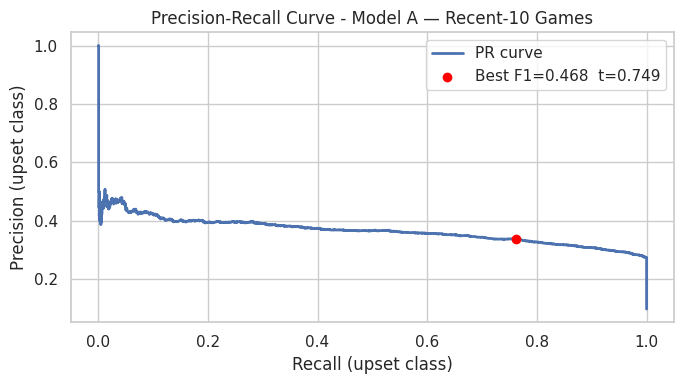

In [102]:

print("  TRAINING MODEL A — RECENT-10 GAMES")


feat_a = [c for c in r10_train.columns if c not in id_cols + [target]]

X_train_a = r10_train[feat_a]
y_train_a = r10_train[target]
X_test_a  = r10_test[feat_a]
y_test_a  = r10_test[target]

model_a = HistGradientBoostingClassifier(
    max_iter         = 150,
    max_depth        = 3,
    learning_rate    = 0.04,
    min_samples_leaf = 25,
    l2_regularization= 0.04,
    class_weight     = "balanced",
    random_state     = 42,
)

print("  Fitting Model A...")
model_a.fit(X_train_a, y_train_a)
print("  Done.")

result_a = evaluate_model(
    "Model A — Recent-10 Games",
    model_a, X_test_a, y_test_a, feat_a, key = "recent_10",
)

# 7. Full History Model

  TRAINING MODEL B — FULL HISTORY
  Fitting Model B...
  Done.

  Model B — Full History
  Optimal threshold  : 0.753
  ROC-AUC            : 0.8935
  Avg Precision (AP) : 0.3650

              precision    recall  f1-score   support

    No upset      0.971     0.834     0.898     22753
       Upset      0.337     0.771     0.469      2478

    accuracy                          0.828     25231
   macro avg      0.654     0.803     0.683     25231
weighted avg      0.909     0.828     0.855     25231

  Confusion Matrix:
    TN=18985  FP= 3768
    FN=  567  TP= 1911
  [saved] ../output/pr_curve_full_history.pdf


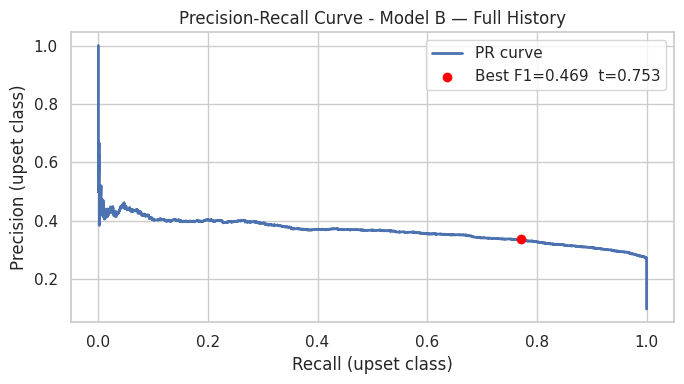

In [103]:

print("  TRAINING MODEL B — FULL HISTORY")


feat_b = [c for c in fh_train.columns if c not in id_cols + [target]]

X_train_b = fh_train[feat_b]
y_train_b = fh_train[target]
X_test_b  = fh_test[feat_b]
y_test_b  = fh_test[target]

model_b = HistGradientBoostingClassifier(
    max_iter         = 150,
    max_depth        = 3,
    learning_rate    = 0.04,
    min_samples_leaf = 25,
    l2_regularization= 0.04,
    class_weight     = "balanced",
    random_state     = 42,
)

print("  Fitting Model B...")
model_b.fit(X_train_b, y_train_b)
print("  Done.")

result_b = evaluate_model(
    "Model B — Full History",
    model_b, X_test_b, y_test_b, feat_b, key = "full_history",
)


## 9. Side-by-Side Comparison

  FINAL COMPARISON
                    Model  Feature window  Upset F1  Best possible F1  ROC-AUC  Threshold
Model A — Recent-10 Games   Last 10 games     0.468             0.468   0.8935      0.749
   Model B — Full History All prior games     0.469             0.469   0.8935      0.753

Original RF baseline (both models, t=0.5): F1 = 0.46
  [saved] ../output/comparison_bar_chart.pdf


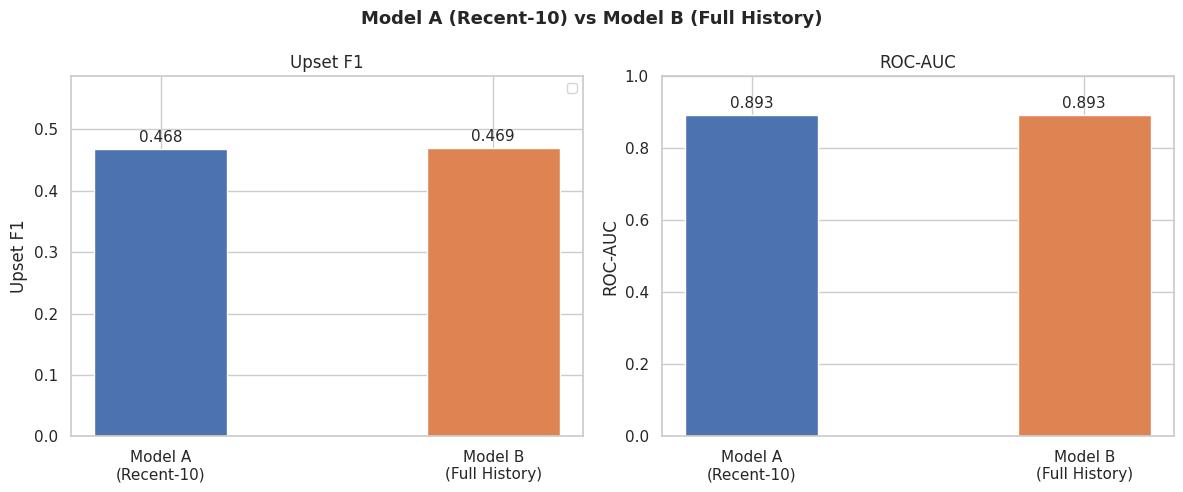

  [saved] ../output/pr_curves_overlay.pdf


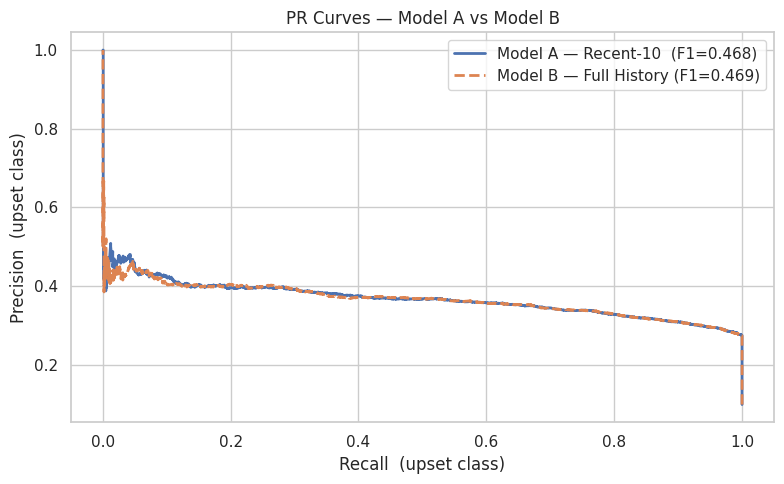


Computing feature importances (permutation, ~15s)...
  Done.
  [saved] ../output/feature_importance_comparison.pdf


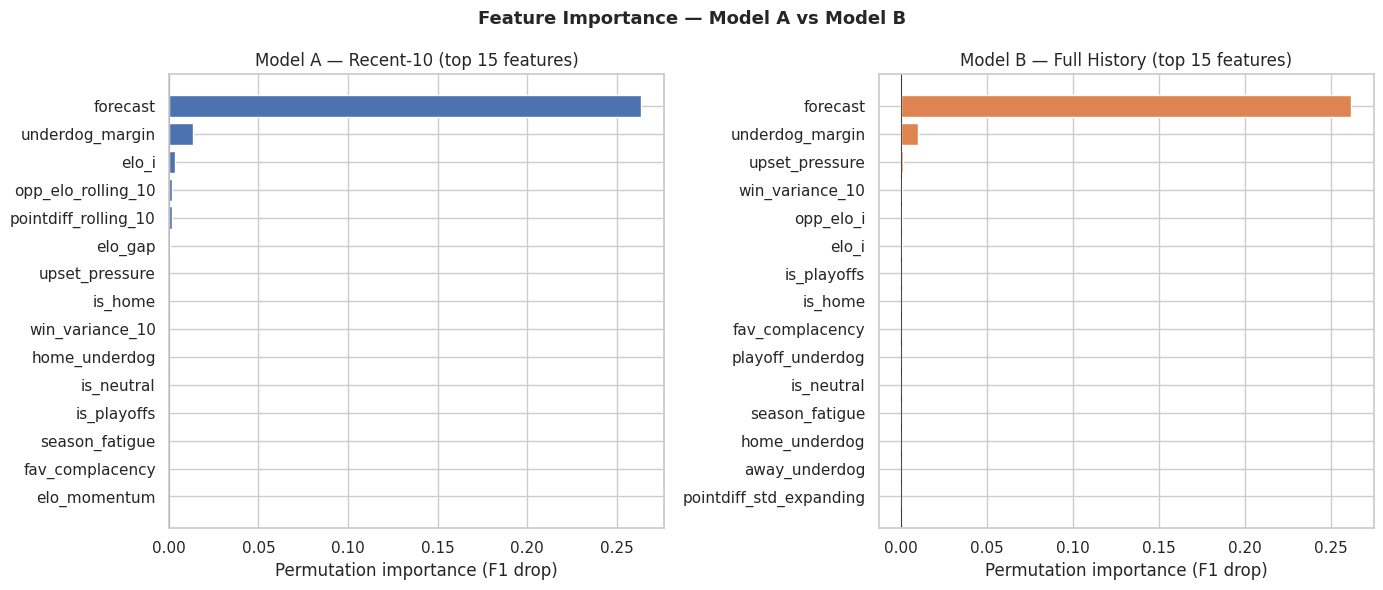

In [104]:
print("  FINAL COMPARISON")


comparison = pd.DataFrame([
    {
        "Model":            result_a["label"],
        "Feature window":   "Last 10 games",
        "Upset F1":         round(result_a["f1_upset"], 3),
        "Best possible F1": round(result_a["best_f1"],  3),
        "ROC-AUC":          round(result_a["roc_auc"],  4),
        "Threshold":        round(result_a["threshold"], 3),
    },
    {
        "Model":            result_b["label"],
        "Feature window":   "All prior games",
        "Upset F1":         round(result_b["f1_upset"], 3),
        "Best possible F1": round(result_b["best_f1"],  3),
        "ROC-AUC":          round(result_b["roc_auc"],  4),
        "Threshold":        round(result_b["threshold"], 3),
    },
])
print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT_DIR / "summary_results.csv", index=False)
print(f"\nOriginal RF baseline (both models, t=0.5): F1 = 0.46")

# ── Bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics    = ["Upset F1", "ROC-AUC"]
model_labels = [
    f"Model A\n(Recent-10)",
    f"Model B\n(Full History)",
]
colors = ["#4C72B0", "#DD8452"]

for ax, metric in zip(axes, metrics):
    vals = [comparison.loc[0, metric], comparison.loc[1, metric]]
    bars = ax.bar(model_labels, vals, color=colors, width=0.4)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
    if metric == "Upset F1":
        ax.legend(fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, min(1.0, max(vals) * 1.25))
    ax.set_ylabel(metric)

plt.suptitle("Model A (Recent-10) vs Model B (Full History)", fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("comparison_bar_chart")

# ── Overlay PR curves ────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(result_a["recalls"][:-1], result_a["precisions"][:-1],
         label=f"Model A — Recent-10  (F1={result_a['best_f1']:.3f})", linewidth=2)
plt.plot(result_b["recalls"][:-1], result_b["precisions"][:-1],
         label=f"Model B — Full History (F1={result_b['best_f1']:.3f})", linewidth=2, linestyle="--")
plt.xlabel("Recall  (upset class)")
plt.ylabel("Precision  (upset class)")
plt.title("PR Curves — Model A vs Model B")
plt.legend()
plt.tight_layout()
savefig("pr_curves_overlay")

# ── Feature importance side-by-side ──────────────────────────
# Uses permutation importance on a 3k subsample of the test set
# (subsampled so it runs in ~15s instead of minutes)
print("\nComputing feature importances (permutation, ~15s)...")
from sklearn.inspection import permutation_importance

N_SAMPLE = 3000

def get_importances(model, X_te, y_te, feats, n_sample=N_SAMPLE):
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_te), size=min(n_sample, len(X_te)), replace=False)
    Xs  = X_te.iloc[idx]
    ys  = y_te.iloc[idx]
    pi  = permutation_importance(
        model, Xs, ys,
        n_repeats=5, scoring="f1", random_state=42, n_jobs=-1,
    )
    return (
        pd.DataFrame({"feature": feats, "importance": pi.importances_mean})
        .sort_values("importance", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )

fi_a = get_importances(model_a, X_test_a, y_test_a, feat_a)
fi_b = get_importances(model_b, X_test_b, y_test_b, feat_b)
print("  Done.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fi, title, color in zip(
    axes,
    [fi_a, fi_b],
    ["Model A — Recent-10 (top 15 features)", "Model B — Full History (top 15 features)"],
    ["#4C72B0", "#DD8452"],
):
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=color)
    ax.set_xlabel("Permutation importance (F1 drop)")
    ax.set_title(title)
    ax.axvline(0, color="black", linewidth=0.5)

plt.suptitle("Feature Importance — Model A vs Model B", fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("feature_importance_comparison")